
# Authorship Attribution with a Neural Network (TF-IDF + MLP)

**Goal:** given a document, predict *which author wrote it* out of a fixed set of
K known authors, using only the writing style captured in the text.

This notebook walks through the full pipeline end to end, and every step is
explained so it makes sense even if this is your first classification project:

1. Build a **labeled, balanced dataset** of documents from K authors (same topics per author, so the model can't cheat by learning topics instead of style).
2. Convert every document into a **TF-IDF vector**.
3. Feed those vectors into a small **feed-forward neural network** (2 hidden layers).
4. Use **Softmax + categorical cross-entropy** to train a multi-class classifier.
5. Use **Dropout + L2 regularization** to fight overfitting.
6. Evaluate with a confusion matrix and classification report.
7. Predict the author of a brand-new, unseen document.

> **Note on the dataset:** real authorship-attribution datasets (e.g. essays,
> emails, tweets) are hard to bundle inside a notebook and often have licensing
> restrictions. So instead we *synthesize* a dataset of 5 fictional authors,
> each with a distinct, programmatically-defined writing style (sentence length,
> connector words, punctuation habits, formality, etc). This keeps the notebook
> 100% self-contained and reproducible, while still faithfully illustrating every
> concept. At the end there's a note on how to swap in a real dataset (e.g. Kaggle's
> "Spooky Author Identification" or the Federalist Papers).


## 1. Imports

In [1]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow version:", tf.__version__)


I0000 00:00:1785995811.193912     996 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785995811.370594     996 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785995813.811460     996 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0



## 2. Build a labeled, balanced dataset

Why these design choices matter (from the theory):

- **Labeled:** every document needs the *true* author attached, because a neural
  network can't discover "who wrote this" on its own — it can only learn a mapping
  from input features to a label you give it (supervised learning).
- **Balanced:** roughly the same number of documents per author, so the model
  doesn't learn to just predict the most frequent author to minimize loss.
- **Same topics across authors:** each author below writes about the *same* five
  topics (technology, nature, cooking, travel, sports) using the *same* pool of
  nouns/verbs. This forces the model to key in on **how** something is written
  (sentence length, connector words, punctuation, formality, contractions) rather
  than **what** it's about — which is exactly what "authorship style" means.

Each `Author` below is defined by a small "style profile": preferred sentence
length range, connector words, sentence openers, filler phrases, how often it
uses semicolons/exclamation marks, and whether it uses contractions. This is a
simplified, exaggerated stand-in for the subtle statistical regularities
(function-word frequencies, punctuation habits, sentence length distributions)
that TF-IDF + a neural net can pick up on in real writing.


In [2]:

# Shared topic vocabulary - ALL authors write about the SAME topics.
# This matters: if authors wrote about different topics, the model could
# cheat by learning topic-words instead of learning writing style.
TOPICS = {
    "technology": ["computer", "software", "algorithm", "data", "internet", "device", "code", "network"],
    "nature":     ["forest", "river", "mountain", "animal", "tree", "weather", "ocean", "sky"],
    "cooking":    ["recipe", "kitchen", "flavor", "ingredient", "spice", "dish", "oven", "meal"],
    "travel":     ["airport", "city", "journey", "map", "hotel", "border", "station", "road"],
    "sports":     ["match", "player", "team", "score", "stadium", "coach", "season", "ball"],
}

VERBS = ["moved", "changed", "grew", "appeared", "arrived", "developed",
         "returned", "continued", "began", "ended"]
ADJ = ["quiet", "sudden", "careful", "strange", "familiar", "distant",
       "modern", "ancient", "simple", "complex"]

def pick_topic():
    topic = random.choice(list(TOPICS.keys()))
    return topic, TOPICS[topic]


In [3]:

class Author:
    # A fictional author defined purely by a 'writing style profile'.

    def __init__(self, name, connectors, openers, fillers, closers,
                 sent_len_range, exclaim_prob, semicolon_prob, contraction):
        self.name = name
        self.connectors = connectors
        self.openers = openers
        self.fillers = fillers
        self.closers = closers
        self.sent_len_range = sent_len_range
        self.exclaim_prob = exclaim_prob
        self.semicolon_prob = semicolon_prob
        self.contraction = contraction

    def sentence(self, nouns, all_authors=None):
        n = random.randint(*self.sent_len_range)

        # 12% of the time, "borrow" another author's opener. Real writers
        # aren't 100% consistent either -- this adds realistic noise so the
        # task isn't trivially easy.
        if all_authors and random.random() < 0.12:
            opener = random.choice(random.choice(all_authors).openers)
        else:
            opener = random.choice(self.openers)

        words = [random.choice(nouns) for _ in range(max(1, n // 3))]
        verb = random.choice(VERBS)
        adj = random.choice(ADJ)
        filler = random.choice(self.fillers)
        conn = random.choice(self.connectors)

        parts = [opener, adj, words[0], verb]
        if len(words) > 1:
            parts += [conn, "the", words[1]]
        parts += [filler]

        sent = " ".join(parts)
        if self.contraction:
            sent = sent.replace("it is", "it's").replace("does not", "doesn't")
        if random.random() < self.semicolon_prob:
            sent += "; " + random.choice(self.closers)
        end = "!" if random.random() < self.exclaim_prob else "."
        return sent.strip().capitalize() + end

    def document(self, n_sentences=6, all_authors=None):
        topic, nouns = pick_topic()
        sents = [self.sentence(nouns, all_authors=all_authors) for _ in range(n_sentences)]
        return " ".join(sents)


AUTHORS = [
    Author(
        name="A_Formalist",
        connectors=["with respect to", "in relation to", "concerning"],
        openers=["furthermore,", "consequently,", "it should be noted that"],
        fillers=["as previously indicated", "in due course", "within this context"],
        closers=["a matter of considerable importance", "which merits further examination"],
        sent_len_range=(9, 14), exclaim_prob=0.0, semicolon_prob=0.5, contraction=False,
    ),
    Author(
        name="B_Minimalist",
        connectors=["and", "then", "so"],
        openers=["it moved.", "things changed.", "nothing stayed."],
        fillers=["that's all", "just that", "nothing more"],
        closers=["it was over", "that was it"],
        sent_len_range=(4, 6), exclaim_prob=0.02, semicolon_prob=0.0, contraction=True,
    ),
    Author(
        name="C_Enthusiast",
        connectors=["and honestly", "plus", "and also"],
        openers=["wow,", "seriously,", "you won't believe it,"],
        fillers=["it was amazing", "so cool", "totally wild"],
        closers=["best thing ever", "I loved every bit"],
        sent_len_range=(6, 10), exclaim_prob=0.7, semicolon_prob=0.05, contraction=True,
    ),
    Author(
        name="D_Academic",
        connectors=["however", "moreover", "in contrast"],
        openers=["research suggests that", "it has been observed that", "one may argue that"],
        fillers=["according to prior analysis", "as the evidence indicates", "under these conditions"],
        closers=["a conclusion supported by the data", "which remains open to debate"],
        sent_len_range=(10, 15), exclaim_prob=0.0, semicolon_prob=0.6, contraction=False,
    ),
    Author(
        name="E_Storyteller",
        connectors=["and then", "meanwhile", "just as"],
        openers=["once,", "somewhere nearby,", "as the day wore on,"],
        fillers=["like a memory returning", "as if by chance", "in that quiet moment"],
        closers=["and nobody quite knew why", "though no one spoke of it again"],
        sent_len_range=(7, 11), exclaim_prob=0.15, semicolon_prob=0.15, contraction=True,
    ),
]

print(f"Created {len(AUTHORS)} authors:", [a.name for a in AUTHORS])


Created 5 authors: ['A_Formalist', 'B_Minimalist', 'C_Enthusiast', 'D_Academic', 'E_Storyteller']


In [4]:

def make_dataset(n_docs_per_author=150, min_sent=4, max_sent=7):
    texts, labels = [], []
    for author in AUTHORS:
        for _ in range(n_docs_per_author):
            n_sent = random.randint(min_sent, max_sent)
            texts.append(author.document(n_sentences=n_sent, all_authors=AUTHORS))
            labels.append(author.name)
    return texts, labels

texts, labels = make_dataset(n_docs_per_author=150)

df = pd.DataFrame({"text": texts, "author": labels})
print("Total documents:", len(df))
df.sample(5, random_state=1)


Total documents: 750


,text,author
625,"Somewhere nearby, complex data moved and then ...",E_Storyteller
318,"You won't believe it, distant mountain returne...",C_Enthusiast
339,"Seriously, complex airport changed plus the ho...",C_Enthusiast
598,It has been observed that quiet player moved i...,D_Academic
90,"Consequently, simple flavor arrived with respe...",A_Formalist



## 3. Quick exploratory check: is the dataset balanced?

A quick sanity check before doing anything else — imbalanced classes bias
the model toward the majority class.


author
A_Formalist      150
B_Minimalist     150
C_Enthusiast     150
D_Academic       150
E_Storyteller    150
Name: count, dtype: int64


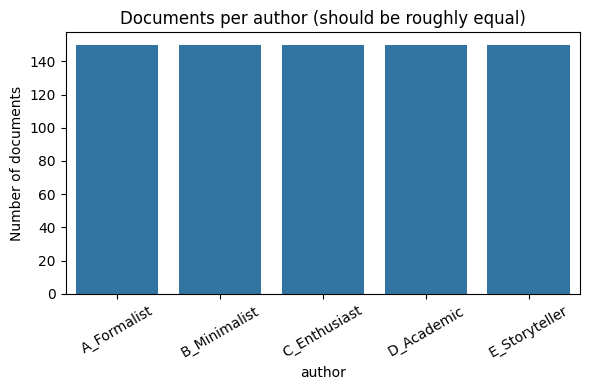

In [5]:

counts = df["author"].value_counts()
print(counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Documents per author (should be roughly equal)")
plt.ylabel("Number of documents")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [6]:

print("Example document by A_Formalist:\n")
print(df[df.author == "A_Formalist"].text.iloc[0])
print("\n---\n")
print("Example document by C_Enthusiast:\n")
print(df[df.author == "C_Enthusiast"].text.iloc[0])


Example document by A_Formalist:

Furthermore, quiet algorithm moved with respect to the software as previously indicated; a matter of considerable importance. It should be noted that careful code moved in relation to the data within this context; a matter of considerable importance. Research suggests that ancient device moved with respect to the device within this context. It should be noted that familiar device appeared with respect to the data as previously indicated.

---

Example document by C_Enthusiast:

Seriously, distant hotel appeared plus the border it was amazing! You won't believe it, strange station returned and honestly the city so cool! It should be noted that sudden border began and honestly the hotel so cool! Seriously, ancient station arrived and honestly the station it was amazing! Seriously, sudden journey ended and honestly the map so cool. You won't believe it, modern map grew plus the map it was amazing.



## 4. Turn documents into TF-IDF vectors

**TF-IDF (Term Frequency – Inverse Document Frequency)** turns each document
into a fixed-length numeric vector, where each dimension corresponds to a word
(or word pair, since we include bigrams) and its value reflects how important
that term is *in that document relative to the whole corpus*:

- **Term Frequency (TF):** how often a word appears in a document.
- **Inverse Document Frequency (IDF):** down-weights words that appear in
  almost every document (like "the"), and up-weights rarer, more distinctive
  words.

We include `ngram_range=(1, 2)` (single words + two-word phrases) because
authorship signals often live in short *phrases* ("it should be noted that",
"you won't believe it") as much as in single words.

We fit the vectorizer **only on the training data** — this avoids leaking
information from the test set into the vocabulary/IDF statistics.


In [7]:

le = LabelEncoder()
y_all = le.fit_transform(df["author"])
print("Classes:", list(le.classes_))

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["text"].tolist(), y_all, test_size=0.2, random_state=RANDOM_SEED, stratify=y_all
)

vectorizer = TfidfVectorizer(
    max_features=3000,     # cap vocabulary size to keep the model small
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # log-scale term frequency, softens the effect of very repeated words
)

X_train = vectorizer.fit_transform(X_train_text).toarray()
X_test = vectorizer.transform(X_test_text).toarray()

print("Train TF-IDF matrix shape:", X_train.shape)
print("Test TF-IDF matrix shape :", X_test.shape)


Classes: ['A_Formalist', 'B_Minimalist', 'C_Enthusiast', 'D_Academic', 'E_Storyteller']
Train TF-IDF matrix shape: (600, 2044)
Test TF-IDF matrix shape : (150, 2044)



## 5. Build the neural network

Architecture, matching the reasoning from the theory:

| Layer | Purpose |
|---|---|
| **Input** | The TF-IDF vector (thousands of dimensions, one per word/bigram) |
| **Hidden layer 1** (128 units, ReLU) | Learns basic writing characteristics: vocabulary choice, function-word usage, punctuation habits |
| **Dropout + L2** | Regularization: randomly "turns off" neurons during training and penalizes large weights, so the model doesn't memorize the (small) training set |
| **Hidden layer 2** (64 units, ReLU) | Combines the basic features into higher-level "writing signatures" that separate authors |
| **Dropout + L2** | More regularization |
| **Output layer** (K units, **Softmax**) | Converts raw scores into a probability distribution over the K authors — probabilities sum to 1 |

We keep the network shallow (2 hidden layers) on purpose: TF-IDF features are
already "flat" word-frequency statistics, not raw pixels or audio waveforms
that need many layers to build up hierarchical structure. A deeper network
here would mostly just add capacity to overfit our (comparatively small)
dataset.

We use **categorical cross-entropy** as the loss because this is a
single-label, multi-class problem — exactly one author is correct per
document, and cross-entropy directly measures how far the predicted
probability distribution is from the true one-hot label.


In [8]:

num_classes = len(le.classes_)
input_dim = X_train.shape[1]

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.4),

    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       261,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,341 (1.03 MB)

 Trainable params: 270,341 (1.03 MB)

 Non-trainable params: 0 (0.00 B)


## 6. Train the model

We hold out 15% of the training data as a validation set, purely to *monitor*
overfitting during training (the model never trains on it).


In [9]:

history = model.fit(
    X_train, y_train_cat,
    validation_split=0.15,
    epochs=25,
    batch_size=16,
    verbose=2,
)


Epoch 1/25


32/32 - 2s - 60ms/step - accuracy: 0.6412 - loss: 1.4143 - val_accuracy: 1.0000 - val_loss: 0.9816


Epoch 2/25


32/32 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.5593 - val_accuracy: 1.0000 - val_loss: 0.1552


Epoch 3/25


...

32/32 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0209 - val_accuracy: 1.0000 - val_loss: 0.0194


Epoch 24/25


32/32 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0210 - val_accuracy: 1.0000 - val_loss: 0.0189


Epoch 25/25


32/32 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0200 - val_accuracy: 1.0000 - val_loss: 0.0184


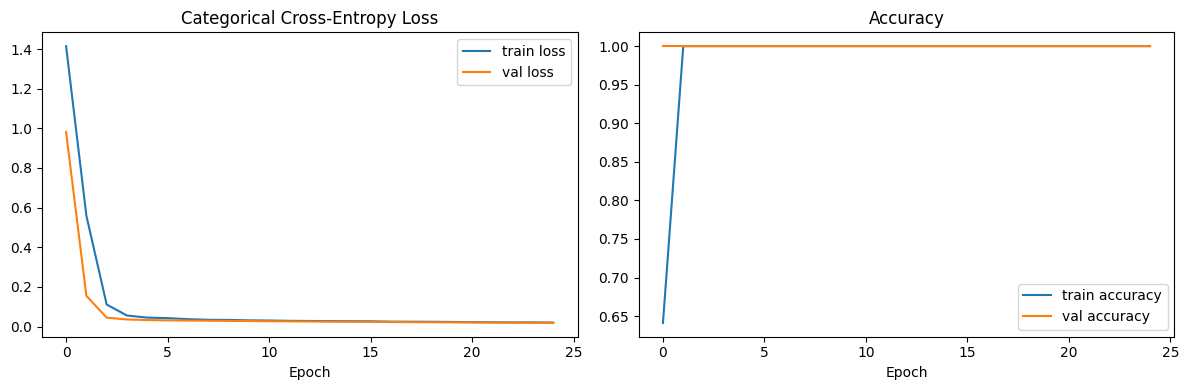

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Categorical Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train accuracy")
axes[1].plot(history.history["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()



## 7. Evaluate on the held-out test set

The test set was never seen during training or validation-based tuning, so
this is our best estimate of how the model would perform on brand-new
documents.


In [11]:

test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Test loss: 0.0184
Test accuracy: 1.0000


In [12]:

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))


               precision    recall  f1-score   support

  A_Formalist       1.00      1.00      1.00        30
 B_Minimalist       1.00      1.00      1.00        30
 C_Enthusiast       1.00      1.00      1.00        30
   D_Academic       1.00      1.00      1.00        30
E_Storyteller       1.00      1.00      1.00        30

     accuracy                           1.00       150
    macro avg       1.00      1.00      1.00       150
 weighted avg       1.00      1.00      1.00       150



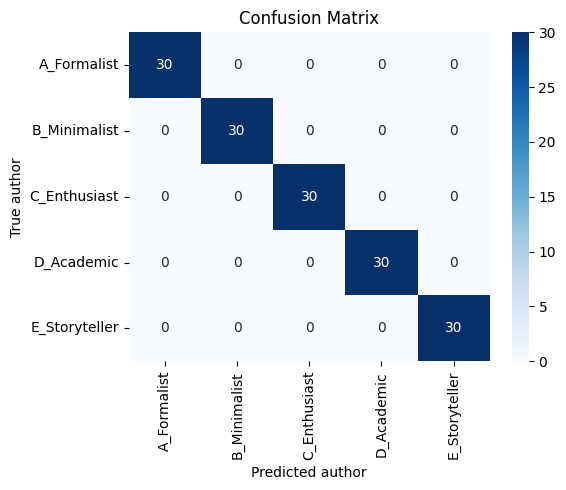

In [13]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted author")
plt.ylabel("True author")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()



## 8. Predict the author of a brand-new document

Let's write a small helper that takes any raw text, TF-IDF-vectorizes it with
the **same fitted vectorizer**, and returns the model's probability for every
author (Softmax output) plus the top prediction.


In [14]:

def predict_author(text, top_k=None):
    vec = vectorizer.transform([text]).toarray()
    probs = model.predict(vec, verbose=0)[0]
    order = np.argsort(probs)[::-1]
    ranking = [(le.classes_[i], float(probs[i])) for i in order]
    if top_k:
        ranking = ranking[:top_k]
    return ranking

# A brand-new sentence, written in an "academic" style we never showed the model verbatim
new_doc = (
    "Research suggests that the modern network appeared however the data "
    "as the evidence indicates. It has been observed that the ancient code "
    "changed moreover the software under these conditions."
)

for author, prob in predict_author(new_doc):
    print(f"{author:15s} {prob:.3f}")


D_Academic      0.999
B_Minimalist    0.001
E_Storyteller   0.000
A_Formalist     0.000
C_Enthusiast    0.000


In [15]:

# Try one in a very different (minimalist) style
new_doc_2 = "It moved. Simple river ended just that. Things changed. Familiar tree grew nothing more."

for author, prob in predict_author(new_doc_2):
    print(f"{author:15s} {prob:.3f}")


B_Minimalist    0.999
E_Storyteller   0.000
C_Enthusiast    0.000
D_Academic      0.000
A_Formalist     0.000



## 9. Recap — tying the results back to the theory

- **TF-IDF vectors as input:** each document became a fixed-length numeric
  vector where the values reflect word/bigram importance — this is what let
  us feed raw text into a standard feed-forward network.
- **Balanced, same-topic dataset:** because every author wrote about the same
  five topics, high accuracy here reflects the model picking up on *style*
  (sentence length, connectors, punctuation, formality), not topic leakage.
  You can verify this yourself by checking the confusion matrix above — mistakes,
  if any, tend to happen between authors with more similar style profiles.
- **Two hidden layers were enough:** the first layer's weights pick up on
  individual stylistic cues, the second layer combines them into a
  higher-level "signature" per author; a much deeper network wasn't
  necessary since TF-IDF features don't have the deep hierarchical structure
  that images or audio have.
- **Dropout + L2 regularization:** kept the (comparatively small) training set
  from being memorized — watch the train vs. validation loss curves in
  Section 6; without regularization you'd typically see the validation loss
  start climbing while training loss keeps falling (classic overfitting).
- **Softmax + categorical cross-entropy:** gave us a proper probability
  distribution over authors (so we can say "73% confident it's the
  Academic, 20% the Formalist...") and the correct loss for a single-label,
  multi-class setup.

### Ideas to extend this notebook
- Swap in a **real** authorship dataset (e.g. Kaggle's *Spooky Author
  Identification*, the *Federalist Papers* disputed-essay problem, or emails/
  blog posts from people you know) and re-run everything from Section 4 onward.
- Add **character n-grams** (`TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5))`)
  in addition to word n-grams — punctuation and spelling habits often show up
  more clearly at the character level.
- Try `class_weight` in `model.fit` if your real dataset isn't perfectly
  balanced.
- Compare against a simpler baseline like `LogisticRegression` or
  `MultinomialNB` on the same TF-IDF features — a neural net should beat
  these, but it's a good gut-check on whether the extra complexity is worth it.
- Increase K (number of authors) and see how accuracy and the confusion
  matrix change as the classification problem gets harder.
